In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

digits = np.arange(10)
mnist = MNISTDataset(ROOT='./torch_datasets/',digits=digits)
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [3]:
set_seed(437438)
def get_model():
    return MLP(
        input_dim=784,
        hidden_dims=[32,32],
        output_dim=len(digits)
    )
mlp_base = get_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [4]:
LOADER_SEED = 645297
batch_size = 64
n_epoch = 10
K = 64
RTOL = 1e-3
LR = 1e-3
LR_SVD = 0.5

### Train MLP with Adam

In [11]:
model_adam = get_model()
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR)
def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1).mean()
    return F.cross_entropy(pred, y, reduction='mean')

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cuda


100%|██████████| 10/10 [00:33<00:00,  3.34s/it]


### Train MLP with Sven

In [12]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_svd = get_model()
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1)
    return F.cross_entropy(pred, y, reduction='none')


model_svd = SvenWrapper(model_svd, loss_fn, device=device, loss_exponent=0.5)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='torch', use_rmsprop=False)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

  0%|          | 0/10 [00:00<?, ?it/s]/n/home11/sambt/iaifi/sv3/sv3/sven/pinv.py:63: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:702.)
  U, S, Vh = torch.linalg.svd(A, full_matrices=False)
  0%|          | 0/10 [00:05<?, ?it/s]


_LinAlgError: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 64).

### compare all three

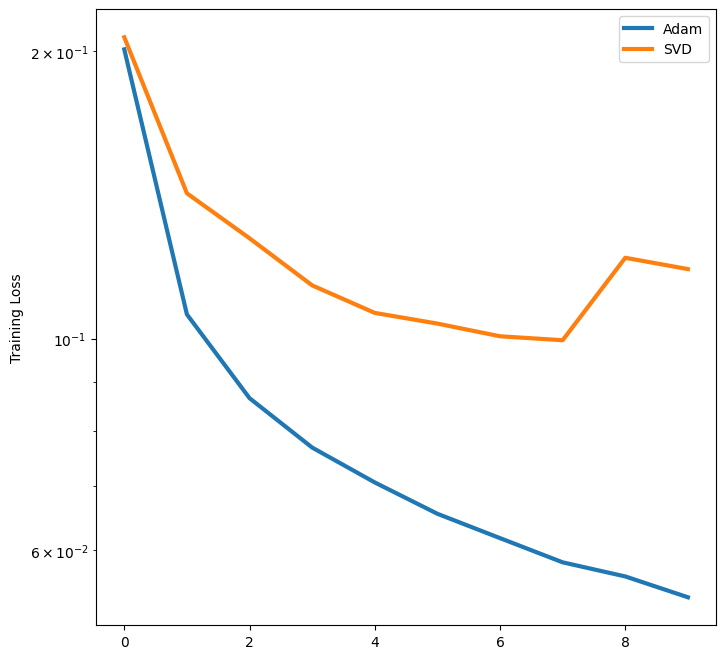

In [7]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['train'],label='Adam',lw=3)
plt.plot(losses_svd['train'],label='SVD',lw=3)
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')

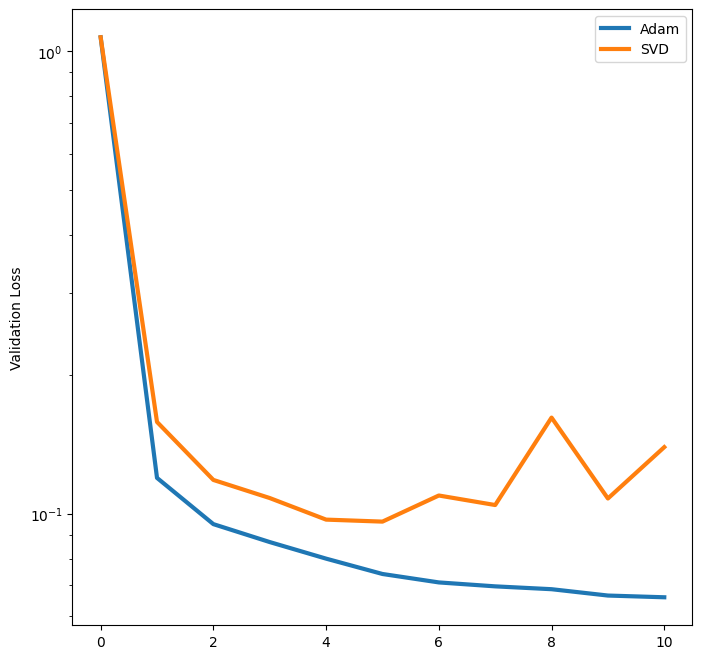

In [9]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['val'],label='Adam',lw=3)
plt.plot(losses_svd['val'],label='SVD',lw=3)
plt.legend()
plt.ylabel("Validation Loss")
plt.yscale('log')